In [14]:
import sys
sys.path.append('../')
import UTILS.utils as utils
import pandas as pd

import spacy
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel

from tqdm import tqdm

## TOPIC MODELLING WITH LATENT DIRICHLET ALLOCATION

In [15]:
# HYPERPARAMETERS TO TUNE
alpha_list = ['symmetric', 'asymmetric', 'auto']
beta_list = ['auto', 'symmetric']
num_topics = range(10, 30, 2)

In [16]:
# tune hyperparams by testing models
def test_hyperparams(dictionary, corpus, texts):
    all_rows = []
    for alpha in tqdm(alpha_list):
        for beta in beta_list:
            for topics in num_topics:
                    model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                                id2word=dictionary,
                                                num_topics=topics, 
                                                alpha=alpha,
                                                eta=beta,
                                                random_state=100,
                                                update_every=1,
                                                chunksize=2000,
                                                passes=20,
                                                per_word_topics=True)
                    coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
                    

                    N = 15  # top-N words
                    topic_words = []
                    for topic_id in range(model.num_topics):
                        top_words = [word for word, _ in model.show_topic(topic_id, topn=N)]
                        topic_words.extend(top_words)

                    # Calculate distinctiveness, coherence and perplexity
                    unique_words = set(topic_words)
                    topic_diversity = len(unique_words) / (N * model.num_topics)

                    log_perplexity = model.log_perplexity(corpus)
                    actual_perplexity = 2 ** (-log_perplexity)

                    this_row = [alpha, beta, topics, coherencemodel.get_coherence(), actual_perplexity, topic_diversity]
                    all_rows.append(this_row)
    return all_rows

In [17]:
# utility functions

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def test_token(token):
    return token.is_stop or token.is_digit or token.is_punct # returns True if token is stopword, digit or punctuation

# remove item from list
def remove_items(test_list, item):
    res = [i for i in test_list if i != item]
    return res

# tokenize sentences
def tokenize(sentence):
    sentence = sentence.lower()
    sentence = remove_items(str(sentence), "\n")
    doc = nlp("".join(sentence))
    filtered_tokens = [token.text for token in doc if not test_token(token)]
    return filtered_tokens

# lemmatize tokens
def lemmatize(text):
    doc = nlp(" ".join(text))
    return [token.lemma_ for token in doc]

### SENTENCES

In [18]:
all_sentences = pd.read_csv(utils.ALL_SENTENCES_DF)
df = pd.DataFrame(all_sentences, columns=["text"])

In [19]:
df["tokens"] = df["text"].apply(tokenize)

# create bigrams
bigram = gensim.models.Phrases(df["text"].to_list(), min_count=5, threshold=100) # higher threshold fewer phrases.
bigram_mod = gensim.models.phrases.Phraser(bigram)

def make_bigrams(text):
    return bigram_mod[text] 

df["to_lemmatize"] = df["tokens"].apply(make_bigrams)
df['lemmas'] = df['to_lemmatize'].apply(lemmatize)

In [20]:
id2word = corpora.Dictionary(df['lemmas']) # create vocabulary
texts = df['lemmas'].to_list() # get list of lemmas
corpus = [id2word.doc2bow(text) for text in texts] # create corpus

In [ ]:
hyperparams = test_hyperparams(dictionary=id2word, corpus=corpus, texts=df['lemmas'].tolist())
hyperparams_df = pd.DataFrame(hyperparams, columns=["symmetric", "auto", "num_topics", "coherence", "perplexity", "diversity"])
hyperparams_df.to_csv("../../Data/HYPERPARAMS/LDA_sentences.csv")

In [15]:
hyperparams_df = pd.read_csv("../../Data/HYPERPARAMS/LDA_sentences.csv")
maxidx_coherence = hyperparams_df[["coherence"]].idxmax()
maxidx_diversity = hyperparams_df[["diversity"]].idxmax()
minidx_perplexity = hyperparams_df[["perplexity"]].idxmin()


In [16]:
# show best params to maximize coherence (chosen metric)
hyperparams_df.iloc[maxidx_coherence]

,Unnamed: 0,symmetric,auto,num_topics,coherence,perplexity,diversity
28,28,asymmetric,auto,26,0.468387,583.878067,0.805128


In [35]:
# create final model and print topics
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                            id2word=id2word,
                                            num_topics=26, 
                                            random_state=100,
                                            update_every=1,
                                            chunksize=2000,
                                            passes=10,
                                            alpha='asymmetric',
                                            eta='auto',
                                            per_word_topics=True)

In [38]:
lda_model.num_topics

26

In [39]:
import re

topics = lda_model.print_topics(num_words=8, num_topics=26)
for topic in topics:
    t = re.findall(r'"([^"]*)"', topic[1])
    s = "\item" + "\\" + "v" + "space{-0.2cm}["
    for w in t[:-1]:
        s += w + ", "
    s += t[-1] + "]"
    print(s)

\item\vspace{-0.2cm}[foot, red, chinese, government, pekin, boat, china, yamên]
\item\vspace{-0.2cm}[street, chinese, carry, yuen, like, great, coolie, china]
\item\vspace{-0.2cm}[instrument, chinese, state, king, probably, consider, day, circle]
\item\vspace{-0.2cm}[leave, wall, city, pass, stand, look, right, place]
\item\vspace{-0.2cm}[see, bring, chinese, woman, far, bronze, time, high]
\item\vspace{-0.2cm}[chinese, china, building, little, affair, time, degree, palace]
\item\vspace{-0.2cm}[friend, stand, give, way, umbrella, howl, representative, silk]
\item\vspace{-0.2cm}[prince, legation, mile, shall, time, foreign, prove, see]
\item\vspace{-0.2cm}[notice, international, formality, country, hat, cap, ming, partially]
\item\vspace{-0.2cm}[find, expect, hand, time, spirit, guest, result, obtain]
\item\vspace{-0.2cm}[sex, appoint, street, interesting, great, remind, let, chair]
\item\vspace{-0.2cm}[tea, divide, ask, part, nation, serve, drink, fair]
\item\vspace{-0.2cm}[year, siege

<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_74423/3268402327.py:6: SyntaxWarning: invalid escape sequence '\i'
  s = "\item" + "\\" + "v" + "space{-0.2cm}["


In [11]:
### CREATING GRAPH

doc_topic_distributions = [lda_model.get_document_topics(bow, minimum_probability=0.0) for bow in corpus]
document_dominant_topics = []
for i, doc_topics in enumerate(doc_topic_distributions):
    if doc_topics: 
        dominant_topic = max(doc_topics, key=lambda item: item[1])[0]
        document_dominant_topics.append(dominant_topic)
    else:
        document_dominant_topics.append(None)

from collections import Counter

topic_counts = Counter(document_dominant_topics)

all_topic_ids = list(range(26))
documents_per_topic = {topic_id: topic_counts.get(topic_id, 0) for topic_id in all_topic_ids}

plot_data = pd.DataFrame(list(documents_per_topic.items()), columns=['Topic ID', 'Number of Documents'])
plot_data = plot_data.sort_values(by='Topic ID') 
plot_data_sorted = plot_data.sort_values(by='Number of Documents', ascending=False)
topic_order = plot_data_sorted['Topic ID'].tolist()


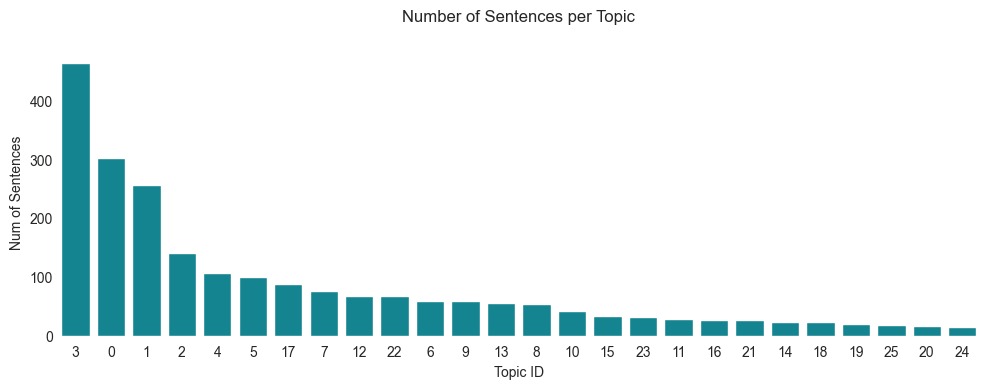

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

sns.set_style("white") 
plt.figure(figsize=(10, 4)) 

ax = sns.barplot(x='Topic ID', y='Number of Documents', data=plot_data_sorted,
                 order=topic_order,
                 color='#0094a6') 

plt.xlabel('Topic ID') 
sns.despine(left=True, bottom=True, top=True, right=True)
ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
plt.ylabel('Num of Sentences')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.title('Number of Sentences per Topic', pad=20)

plt.tight_layout()
plt.show()

### PARAGRAPHS

In [5]:
all_paragraphs = pd.read_csv("../../Data/TEXT/ALL_PARAGRAPHS.csv")
df_paragraphs = pd.DataFrame(all_paragraphs, columns=["text"])

In [6]:
df_paragraphs["tokens"] = df_paragraphs["text"].apply(tokenize)

bigram_paragraph = gensim.models.Phrases(df_paragraphs["text"].to_list(), min_count=5, threshold=100) # higher threshold fewer phrases.
bigram_mod_paragraph = gensim.models.phrases.Phraser(bigram_paragraph)

def make_bigrams_paragraph(text):
    return bigram_mod_paragraph[text] 

df_paragraphs["to_lemmatize"] = df_paragraphs["tokens"].apply(make_bigrams_paragraph)
df_paragraphs['lemmas'] = df_paragraphs['to_lemmatize'].apply(lemmatize)

In [7]:
id2word_paragraphs = corpora.Dictionary(df_paragraphs['lemmas'])
texts_paragraphs = df_paragraphs['lemmas'].to_list()
corpus_paragraphs = [id2word_paragraphs.doc2bow(text) for text in texts_paragraphs]

In [8]:
hyperparams_paragraphs = test_hyperparams(dictionary=id2word_paragraphs, corpus=corpus_paragraphs, texts=texts_paragraphs)

100%|██████████| 3/3 [10:45<00:00, 215.33s/it]


In [11]:
hyperparams_df_paragraphs = pd.DataFrame(hyperparams_paragraphs, columns=["symmetric", "auto", "num_topics", "coherence", "perplexity", "diversity"])
hyperparams_df_paragraphs.to_csv("../../Data/HYPERPARAMS/LDA_paragraphs.csv")

In [12]:
hyperparams_df_paragraphs = pd.read_csv("../../Data/HYPERPARAMS/LDA_paragraphs.csv")
maxidx_coherence = hyperparams_df_paragraphs[["coherence"]].idxmax()
maxidx_diversity = hyperparams_df_paragraphs[["diversity"]].idxmax()
minidx_perplexity = hyperparams_df_paragraphs[["perplexity"]].idxmin()


In [13]:
hyperparams_df_paragraphs.iloc[maxidx_coherence]

,Unnamed: 0,symmetric,auto,num_topics,coherence,perplexity,diversity
29,29,asymmetric,auto,28,0.318951,410.087536,0.466667


In [14]:
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus_paragraphs,
                                            id2word=id2word_paragraphs,
                                            num_topics=28, 
                                            random_state=100,
                                            update_every=1,
                                            chunksize=2000,
                                            passes=10,
                                            alpha='asymmetric',
                                            eta='auto',
                                            per_word_topics=True)

topics = lda_model.print_topics(num_words=10)
for topic in topics:
    print(topic)

(27, '0.015*"gate" + 0.009*"chinese" + 0.009*"man" + 0.006*"foot" + 0.005*"time" + 0.005*"china" + 0.005*"place" + 0.005*"cage" + 0.005*"city" + 0.004*"remove"')
(26, '0.011*"river" + 0.010*"mile" + 0.008*"wall" + 0.007*"great" + 0.006*"place" + 0.006*"city" + 0.005*"find" + 0.005*"lake" + 0.005*"boat" + 0.005*"foot"')
(25, '0.021*"degree" + 0.008*"honor" + 0.008*"examination" + 0.006*"applicant" + 0.006*"high" + 0.006*"government" + 0.006*"bamboo" + 0.006*"pekin" + 0.004*"learn" + 0.004*"obtain"')
(24, '0.012*"bridge" + 0.009*"street" + 0.009*"gate" + 0.008*"pass" + 0.007*"woman" + 0.007*"tower" + 0.006*"reach" + 0.006*"legation" + 0.006*"canal" + 0.006*"boat"')
(23, '0.009*"prince" + 0.007*"palace" + 0.006*"china" + 0.006*"boxer" + 0.005*"cause" + 0.005*"chinese" + 0.005*"great" + 0.005*"ching" + 0.005*"hand" + 0.004*"find"')
(22, '0.008*"leave" + 0.006*"american" + 0.006*"near" + 0.005*"lie" + 0.005*"hill" + 0.005*"little" + 0.005*"china" + 0.005*"city" + 0.005*"mile" + 0.005*"land"